# Charting Boulder: License Plate Readers
[Brian C. Keegan, Ph.D.](http://www.brianckeegan.com)  
June 2026

Released under a [MIT License](https://opensource.org/licenses/MIT).

This notebook analyzes **Boulder Police Department's own license-plate-reader search audit** against the privacy promises in the city's pending ALPR procurement (RFP 24-2026) and against the state surveillance bill, SB26-070, that failed in May 2026.

**Primary data.** One row per plate search *performed by Boulder PD users*, Dec 1 2024 – Jun 12 2025, from Flock's **Organization Audit** for Boulder CO PD. The public copy is mirrored by [DeFlock](https://blog.deflock.me/alprs-in-boulder/) ([CSV](https://blog.deflock.me/assets/docs/boulder-co-pd.csv)); a snapshot is committed alongside this notebook. Its search rate is cross-validated below against the official [Flock transparency portal](https://transparency.flocksafety.com/boulder-co-pd).

**Libraries.** Only `pandas`, `numpy`, and `matplotlib` (all base Anaconda). No API keys.

See `data/raw/README.md` for every source URL, and the *Limits* section at the end for the boundary of what this audit can and cannot show.

In [13]:
import pandas as pd
import numpy as np

import re
import html
from curl_cffi import requests as creq

pd.options.display.max_columns = 100

%matplotlib inline
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick

## Load the data

### Boulder PD search audit (Flock Organization Audit)
Committed snapshot `boulder-co-pd_org-audit_2025-06-12.csv` (falls back to the DeFlock URL if the local file is absent). Each row is one search a Boulder PD user ran against the Flock network.

In [4]:
CSV_LOCAL = 'boulder-co-pd_org-audit_2025-06-12.csv'

audit_df = pd.read_csv(CSV_LOCAL)

# Parse the execution timestamp
audit_df['search_time'] = pd.to_datetime(audit_df['search_time_utc'], errors='coerce')

# Inspect a focused slice (the file has a self-join tail of org-identity columns)
cols = ['name','license_plate','reason','case_number','total_networks_searched',
        'total_devices_searched','search_time']
print(audit_df.shape)
audit_df[cols].head()

(3691, 22)


,name,license_plate,reason,case_number,total_networks_searched,total_devices_searched,search_time
0,N. Tay,DRNX39,wanted,NaN,6540,85619,2025-06-12 22:38:27
1,K. Bro,7209182,25-02463,NaN,6540,85627,2025-06-12 19:14:46
2,N. Tay,SRT8LIZ,stolen,NaN,6544,85634,2025-06-12 16:28:46
3,N. Tay,SRT8LIZ,stolen,NaN,6544,85634,2025-06-12 16:28:18
4,J. Sas,EXD2705,Missing,2505303,6541,85605,2025-06-12 14:32:54


### Integrity checks
Confirm each row is a distinct logged search, establish the date coverage, and validate the search rate against the official portal's "555 searches in the last 30 days" before reporting anything.

In [5]:
# Every row is a distinct audit record (no exact duplicates)
assert audit_df['row_hash'].is_unique, 'duplicate row_hash values'
assert audit_df['id'].is_unique, 'duplicate audit ids'

# This is Boulder CO PD's own audit (single org)
assert (audit_df['name.1'] == 'Boulder CO PD').all()

n_searches = len(audit_df)
d0, d1 = audit_df['search_time'].min(), audit_df['search_time'].max()
coverage_days = (d1 - d0).days
rate_per_30d = n_searches / coverage_days * 30

PORTAL_SEARCHES_30D = 555  # transparency.flocksafety.com/boulder-co-pd, snapshot Nov 27 2025
print(f'searches logged       : {n_searches:,}')
print(f'coverage              : {d0.date()} -> {d1.date()} ({coverage_days} days)')
print(f'implied rate / 30 days: {rate_per_30d:.0f}')
print(f'portal rate / 30 days : {PORTAL_SEARCHES_30D}')
print(f'agreement             : within {abs(rate_per_30d-PORTAL_SEARCHES_30D)/PORTAL_SEARCHES_30D*100:.0f}%'
      ' -> the mirror tracks the official count')

searches logged       : 3,691
coverage              : 2024-12-01 -> 2025-06-12 (193 days)
implied rate / 30 days: 574
portal rate / 30 days : 555
agreement             : within 3% -> the mirror tracks the official count


### Flock transparency portal — Boulder CO PD (official snapshot)
The city points residents to Flock's [transparency portal](https://transparency.flocksafety.com/boulder-co-pd) as the accountability record. These values are pinned to the **Nov 27 2025** retrieval and are not re-fetched at runtime (the portal is a moving snapshot). The agency-access list is reproduced verbatim from that page.

In [15]:
PORTAL_URL = "https://transparency.flocksafety.com/boulder-co-pd"

_FIELDS = {
    "retention_days":   r"The number of days data is retained\.\s*([\d,]+)\s*days",
    "cameras":          r"Number of LPR and other cameras\.\s*([\d,]+)",
    "detections_30d":   r"Number of unique plate reads over the last 30 days\.\s*([\d,]+)",
    "hotlist_hits_30d": r"Total hotlist hits over the last 30 days\.\s*([\d,]+)",
    "searches_30d":     r"Total user search sessions over the last 30 days\.\s*([\d,]+)",
}


def scrape_flock_portal(url=PORTAL_URL, timeout=30):
    """Live Flock transparency portal -> flat dict (incl. agency list). Sync; Jupyter-safe."""
    last = None
    for imp in ("chrome", "chrome124", "safari"):
        r = creq.get(url, impersonate=imp, timeout=timeout)
        last = r.status_code
        if r.status_code == 200 and "Just a moment" not in r.text:
            break
    else:
        raise RuntimeError(f"Cloudflare not cleared (last status {last}); try updating curl_cffi.")

    # Strip tags -> plain text for the labeled stats (no BeautifulSoup needed).
    text = re.sub(r"<(script|style)\b[^>]*>.*?</\1>", " ", r.text, flags=re.I | re.S)
    text = html.unescape(re.sub(r"\s+", " ", re.sub(r"<[^>]+>", " ", text))).strip()

    upd = re.search(r"Last updated:\s*([A-Za-z0-9 ]+?\d{4})", text)
    portal = {"updated": upd.group(1).strip() if upd else None}
    for key, pat in _FIELDS.items():
        m = re.search(pat, text, re.I)
        if not m:
            raise ValueError(f"portal layout changed; pattern not found -> {pat}")
        portal[key] = int(m.group(1).replace(",", ""))

    # "Sharing Network Data With" — each access-table cell carries the agency
    # name verbatim in a data-tp-full-value attribute on the raw HTML.
    orgs = [html.unescape(o).strip()
            for o in re.findall(r'data-tp-full-value="([^"]+)"', r.text)]
    if not orgs:
        raise ValueError("portal layout changed; agency-sharing list not found")
    portal["orgs"] = orgs
    portal["org_count"] = len(orgs)
    return portal


portal = scrape_flock_portal()

portal
# Live as of Sun Jun 14 2026: 90 agencies, e.g.
# 'CO - Colorado Bureau of Investigation', 'Colorado State Patrol',
# 'Northern Colorado Intelligence Unit CO', 'University of Colorado Boulder PD (CO)'


{'updated': 'Sun Jun 14 2026',
 'retention_days': 30,
 'cameras': 31,
 'detections_30d': 659314,
 'hotlist_hits_30d': 8121,
 'searches_30d': 624,
 'orgs': ['Adams County CO SO',
  'Arapahoe County CO SO',
  'Archuleta County CO SO',
  'Arvada CO PD',
  'Aurora CO PD',
  'Avon CO PD',
  'Basalt CO PD',
  'Boulder County CO SO',
  'Breckenridge CO PD',
  'Brighton CO PD',
  'Broomfield CO PD',
  'Castle Rock CO PD',
  'Chaffee County CO SO',
  'Cherry Hills Village CO PD',
  'Cheyenne County CO SO',
  'Clear Creek County CO SO',
  'CO - Colorado Bureau of Investigation',
  'CO - Keenesburg PD',
  'CO - Rangely PD',
  'CO - Steamboat Springs PD',
  'Colorado State Parks',
  'Colorado State Patrol',
  'Columbine Valley CO PD',
  'Commerce City CO PD',
  'Custer County CO SO',
  'Dacono CO PD',
  'Douglas County CO SO',
  'Douglas County Open Spaces & Natural Resources CO',
  'Durango CO PD',
  'Eaton CO PD',
  'Edgewater CO PD',
  'El Paso CO SO',
  'Elizabeth CO PD',
  'Englewood CO PD',


In [16]:
n_orgs = len(portal['orgs'])
print(f"{n_orgs} Colorado organizations granted access (portal, {portal['updated']})")
print(f"{portal['detections_30d']:,} vehicle detections / 30 days on Boulder's {portal['cameras']} cameras")

90 Colorado organizations granted access (portal, Sun Jun 14 2026)
659,314 vehicle detections / 30 days on Boulder's 31 cameras


## Descriptive overview

Basic shape of the search record, for orienting numbers the column can reference before the findings. Timestamps are converted from UTC to Mountain Time for the time-of-day summary.

In [17]:
# Volume
per_day  = n_searches / coverage_days
per_week = per_day * 7

# Who searched (users redacted to initials in the source)
user_counts = audit_df['name'].value_counts()
n_users      = audit_df['name'].nunique()
top_user_n   = int(user_counts.iloc[0])
top6_share   = user_counts.head(6).sum() / n_searches * 100

# Search type: plate lookups vs vehicle-description searches
type_counts = audit_df['search_type'].value_counts(dropna=False)

# Plates: a small set, mostly searched repeatedly
plate_counts    = audit_df['license_plate'].dropna().value_counts()
n_unique_plates = int(plate_counts.size)
pct_plates_repeat = (plate_counts > 1).mean() * 100

# How often a search found nothing
pct_no_match = (audit_df['total_devices_searched'] == 0).mean() * 100

# Justification length
reason_words   = audit_df['reason'].astype(str).str.strip().str.split().str.len()
pct_single_word = (reason_words <= 1).mean() * 100

# Time of day (Mountain Time)
local_time = audit_df['search_time'].dt.tz_localize('UTC').dt.tz_convert('America/Denver')
hour = local_time.dt.hour
pct_overnight = ((hour >= 0) & (hour < 6)).mean() * 100  # 12 a.m.-6 a.m.

overview = pd.Series({
    'searches':                 f'{n_searches:,}',
    'coverage':                 f'{d0.date()} to {d1.date()} ({coverage_days} days)',
    'searches per day (avg)':   f'{per_day:.0f}',
    'searches per week (avg)':  f'{per_week:.0f}',
    'distinct users (officers)':n_users,
    'busiest user':             f'{top_user_n:,} searches ({top_user_n/n_searches*100:.0f}%)',
    'top 6 users share':        f'{top6_share:.0f}%',
    'plate lookups':            int(type_counts.get('lookup', 0)),
    'vehicle-description searches': int(type_counts.get('search', 0)),
    'distinct plates searched': n_unique_plates,
    'plates searched >1x':      f'{pct_plates_repeat:.0f}% of distinct plates',
    'searches returning no match': f'{pct_no_match:.0f}%',
    'single-word justifications': f'{pct_single_word:.0f}%',
    'searches 12 a.m.-6 a.m.':  f'{pct_overnight:.0f}% (most are daytime)',
})
overview

searches                                                      3,691
coverage                        2024-12-01 to 2025-06-12 (193 days)
searches per day (avg)                                           19
searches per week (avg)                                         134
distinct users (officers)                                        60
busiest user                                     714 searches (19%)
top 6 users share                                               70%
plate lookups                                                  1777
vehicle-description searches                                     75
distinct plates searched                                        539
plates searched >1x                          91% of distinct plates
searches returning no match                                     38%
single-word justifications                                      96%
searches 12 a.m.-6 a.m.                       4% (most are daytime)
dtype: object

Two of these feed the findings directly: justifications are almost always one word (reinforcing Finding 1), and the 3,691 searches cover only a few hundred distinct plates, most queried repeatedly — the system is used less for one-off lookups than for repeated checks on a small set of vehicles. (A handful of plates are searched dozens of times; the single most-searched plate appears more than 250 times. High repeat counts may reflect sustained interest in a specific vehicle and are descriptive only.)

## Finding 1 — The 'valid reason' is an unverified text box

Boulder's published Access Policy states that *all system access requires a valid reason*, and the RFP's requirements spreadsheet (Appendix C, row 134) asks vendors for a "mandatory user-defined search justification field." The audit shows what that field actually holds.

In [18]:
# Normalize the reason text (case/whitespace) without changing meaning
reason = audit_df['reason'].astype(str).str.strip()
reason_norm = reason.str.lower()

# Is a search tied to a case? Either the structured case_number field, or a reason that *is* a case number
case_pattern = re.compile(r'^\d{2}-?\d{2,}$')
reason_is_caselike = reason_norm.str.match(case_pattern).fillna(False)
has_case_number = audit_df['case_number'].notna()
case_linked = has_case_number | reason_is_caselike

pct_case_linked = case_linked.mean() * 100
pct_free_text   = 100 - pct_case_linked
n_distinct_reasons = reason_norm.nunique()

print(f'searches tied to a case number : {case_linked.sum():,} ({pct_case_linked:.1f}%)')
print(f'searches with free-text reason : {(~case_linked).sum():,} ({pct_free_text:.1f}%)')
print(f'single-word justifications     : {pct_single_word:.0f}%')
print(f'distinct reason strings        : {n_distinct_reasons}')

searches tied to a case number : 65 (1.8%)
searches with free-text reason : 3,626 (98.2%)
single-word justifications     : 96%
distinct reason strings        : 103


The field has no controlled vocabulary: the same justification is logged in several spellings and cases, so it cannot be aggregated or audited reliably.

In [19]:
for stem in ['stolen', 'warrant', 'suspicious']:
    variants = reason[reason_norm == stem].value_counts().to_dict()
    print(f'{stem!r:14} logged as -> {variants}')

'stolen'       logged as -> {'STOLEN': 275, 'Stolen': 221, 'stolen': 98}
'warrant'      logged as -> {'warrant': 145, 'Warrant': 94, 'WARRANT': 38}
'suspicious'   logged as -> {'Suspicious': 581, 'suspicious': 6}


The most common entries, as officers typed them (normalized for case):

In [20]:
top_reasons = reason_norm.value_counts().head(15)
modal_reason = top_reasons.index[0]
modal_n = int(top_reasons.iloc[0])
print(f'modal reason = {modal_reason!r}  ({modal_n:,} searches, {modal_n/n_searches*100:.0f}%)')
top_reasons

modal reason = 'stolen'  (594 searches, 16%)


reason
stolen        594
suspicious    587
police        344
warrant       277
threats       252
dv            153
atl           151
223           116
kidnap         96
interest       93
250            65
sus            57
lost           55
212            48
inv            44
Name: count, dtype: int64

### Draft chart — what Boulder PD typed in the 'reason' box

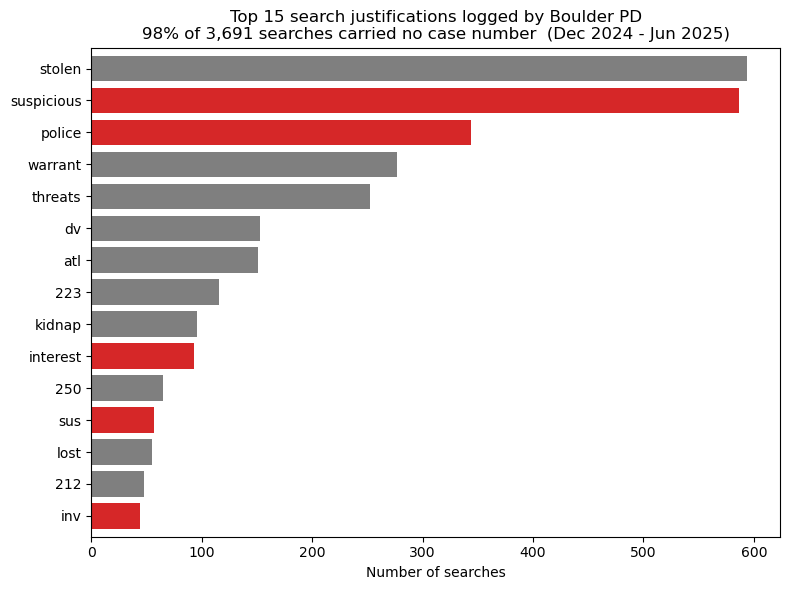

In [21]:
f, ax = plt.subplots(figsize=(8, 6))
tr = top_reasons.iloc[::-1]   # ascending for horizontal bars

# Gray the field; highlight the two that name no specific incident
vague = {'suspicious', 'police', 'interest', 'inv', 'sus', 'pd', 'crime'}
colors = ['tab:red' if r in vague else 'tab:gray' for r in tr.index]

tr.plot(kind='barh', ax=ax, color=colors, width=0.8)
ax.set_xlabel('Number of searches')
ax.set_ylabel('')
ax.set_title('Top 15 search justifications logged by Boulder PD\n'
             f'{pct_free_text:.0f}% of {n_searches:,} searches carried no case number  '
             '(Dec 2024 - Jun 2025)')
ax.margins(y=0.01)
plt.tight_layout()
# plt.savefig('chart1_search_reasons.png', dpi=150, bbox_inches='tight')
plt.show()

## Finding 2 — A single Boulder search reaches a national mesh

The transparency portal lists ~90 Colorado agencies. But each row records how many networks and devices the query actually spanned. Boulder "left the national network" for *outbound sharing* in June 2025 — yet its officers' *searches* in this window reached far beyond Colorado.

In [22]:
net = audit_df['total_networks_searched']
dev = audit_df['total_devices_searched']

min_networks    = int(net.min())
median_networks = int(net.median())
median_devices  = int(dev[dev > 0].median())
max_devices     = int(dev.max())
pct_over_1000   = (net > 1000).mean() * 100

print(f'every search reached at least : {min_networks:,} networks')
print(f'median networks per search    : {median_networks:,}')
print(f'share reaching >1,000 networks: {pct_over_1000:.0f}%')
print(f'median cameras per search*    : {median_devices:,}   (*among searches returning a match)')
print(f'most cameras in one search    : {max_devices:,}')
print(f'...vs Colorado agencies listed on the portal: {n_orgs}')

every search reached at least : 4,766 networks
median networks per search    : 5,994
share reaching >1,000 networks: 100%
median cameras per search*    : 76,444   (*among searches returning a match)
most cameras in one search    : 85,634
...vs Colorado agencies listed on the portal: 90


### Draft chart — networks queried per search, against the portal's Colorado-only picture

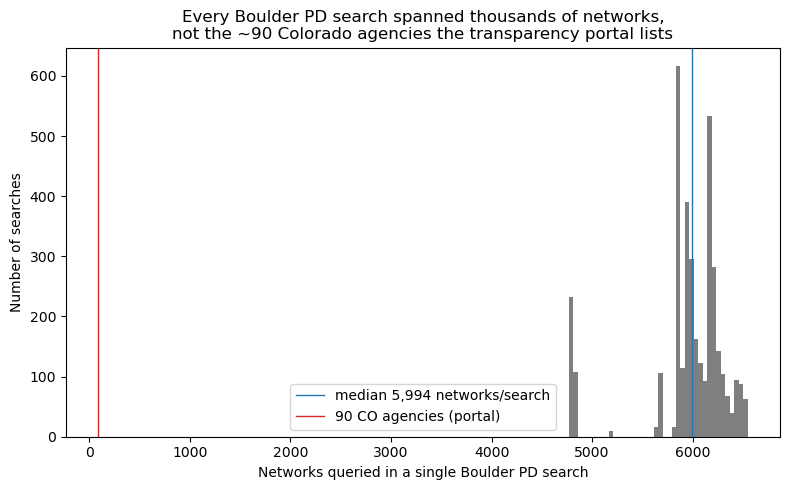

In [24]:
f, ax = plt.subplots(figsize=(8, 5))
ax.hist(net, bins=40, color='tab:gray')
ax.axvline(net.median(), color='tab:blue', lw=1, label=f'median {median_networks:,} networks/search')
ax.axvline(n_orgs, color='tab:red', lw=1,
           label=f'{n_orgs} CO agencies (portal)')
ax.set_xlabel('Networks queried in a single Boulder PD search')
ax.set_ylabel('Number of searches')
ax.set_title('Every Boulder PD search spanned thousands of networks,\n'
             'not the ~90 Colorado agencies the transparency portal lists')
ax.legend()

plt.tight_layout()
# plt.savefig('chart2_search_reach.png', dpi=150, bbox_inches='tight')
plt.show()

## Finding 3 — Boulder's own data flows into a statewide web

The reach above is Boulder searching outward. The reciprocal — *who can search Boulder's cameras* — is the portal's access list: ~90 Colorado agencies, including a state investigative bureau, the state patrol, a regional fusion center, and an agency that has confirmed ICE cooperation.

In [26]:
flag_terms = ['Bureau of Investigation', 'State Patrol', 'Intelligence Unit',
              'El Paso', 'Anschutz', 'Boulder PD (CO']
flagged = [o for o in portal['orgs'] if any(t in o for t in flag_terms)]
print(f'{n_orgs} Colorado organizations can search Boulder data. Notable:')
for o in flagged:
    print('   -', o)
print()
print('Reported but NOT reproduced here (inbound Network Audit, MuckRock FOIA, July 2025):')
print('   Boulder was on Flock\'s national network -> thousands of agencies, incl. out-of-state and')
print('   federal, with searches logged for reasons including "immigration." See data/raw/README.md.')

90 Colorado organizations can search Boulder data. Notable:
   - CO - Colorado Bureau of Investigation
   - Colorado State Patrol
   - El Paso CO SO
   - Northern Colorado Intelligence Unit CO
   - University of Colorado Anschutz Medical Campus CO PD
   - University of Colorado Boulder PD (CO)

Reported but NOT reproduced here (inbound Network Audit, MuckRock FOIA, July 2025):
   Boulder was on Flock's national network -> thousands of agencies, incl. out-of-state and
   federal, with searches logged for reasons including "immigration." See data/raw/README.md.


## Pinned headline numbers
Every figure the column may quote, computed from the data above.

In [27]:
print('PINNED NUMBERS FOR THE COLUMN')
print('-'*48)
print(f'searches logged (Dec 2024-Jun 2025) : {n_searches:,}')
print(f'implied searches per 30 days        : {rate_per_30d:.0f}  (portal: 555)')
print(f'searches per day (avg)              : {n_searches/coverage_days:.0f}')
print(f'searches per week (avg)             : {per_week:.0f}')
print(f'distinct users (officers)           : {n_users}')
print(f'busiest 6 users, share of searches  : {top6_share:.0f}%')
print(f'distinct plates searched            : {n_unique_plates}  ({pct_plates_repeat:.0f}% queried >1x)')
print(f'searches returning no match         : {pct_no_match:.0f}%')
print(f'% with no case number (free text)   : {pct_free_text:.0f}%')
print(f'% single-word justifications        : {pct_single_word:.0f}%')
print(f'distinct reason strings             : {n_distinct_reasons}')
print(f'modal reason                        : {modal_reason!r} ({modal_n:,}, {modal_n/n_searches*100:.0f}%)')
print(f'min networks reached by any search  : {min_networks:,}')
print(f'median networks per search          : {median_networks:,}')
print(f'median cameras per matched search   : {median_devices:,}')
print(f'CO agencies with access (portal)    : {n_orgs}')
print(f'vehicle detections / 30 days        : {portal["detections_30d"]:,}')
print(f'retention                           : {portal["retention_days"]} days')

PINNED NUMBERS FOR THE COLUMN
------------------------------------------------
searches logged (Dec 2024-Jun 2025) : 3,691
implied searches per 30 days        : 574  (portal: 555)
searches per day (avg)              : 19
searches per week (avg)             : 134
distinct users (officers)           : 60
busiest 6 users, share of searches  : 70%
distinct plates searched            : 539  (91% queried >1x)
searches returning no match         : 38%
% with no case number (free text)   : 98%
% single-word justifications        : 96%
distinct reason strings             : 103
modal reason                        : 'stolen' (594, 16%)
min networks reached by any search  : 4,766
median networks per search          : 5,994
median cameras per matched search   : 76,444
CO agencies with access (portal)    : 90
vehicle detections / 30 days        : 659,314
retention                           : 30 days


## Export the chart slice
The top-reasons table feeds the published (Datawrapper) chart.

In [28]:
reason_summary = (reason_norm.value_counts().rename_axis('reason')
                  .reset_index(name='searches'))
reason_summary['is_case_linked'] = reason_summary['reason'].str.match(case_pattern).fillna(False)
# reason_summary.to_csv('reason_summary_for_datawrapper.csv', index=False)
reason_summary.head(15)

,reason,searches,is_case_linked
0,stolen,594,False
1,suspicious,587,False
2,police,344,False
3,warrant,277,False
4,threats,252,False
5,dv,153,False
6,atl,151,False
7,223,116,False
8,kidnap,96,False
9,interest,93,False


## Limits

- **Scope of this audit.** These are Boulder PD's **outbound** searches (Flock's Organization Audit). The **inbound** Network Audit — other agencies searching Boulder's cameras, where the national-network and "immigration" reasons appear — is a separate FOIA'd record ([MuckRock](https://www.muckrock.com/foi/boulder-172/boulder-alpr-audits-187797/)); it is cited as reported context, not reproduced here.
- **Descriptive, not causal.** The analysis describes how searches were *logged*. It does not establish whether any individual search was legally justified, only that the recorded justification is unstructured free text in ~98% of cases.
- **No time trend.** Monthly counts are **not** reported: the mirror appears to capture a rolling trailing window as of the mid-June 2025 scrape, so apparent month-to-month changes are an export artifact, not a behavioral trend.
- **Reach metric.** `total_networks_searched` (never zero; min 4,766) is used for reach; `total_devices_searched` is reported only among searches that returned a match (about 38% returned none).
- **Portal is a moving snapshot.** Transparency-portal values are pinned to the Nov 27 2025 retrieval and may differ today.

*The data and code for replicating these analyses can be found on GitHub.*